In [23]:
!cp /content/urdu_embeddings_from_tuned_xlmr_final.csv /content/drive/MyDrive/urdu_embeddings_from_tuned_xlmr_final.csv

cp: cannot stat '/content/urdu_embeddings_from_tuned_xlmr_final.csv': No such file or directory


In [24]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)

class SimpleVATTEmotionPredictor(nn.Module):
    def __init__(self, text_dim, video_dim, common_space_dim, hidden_dim, num_classes):
        super(SimpleVATTEmotionPredictor, self).__init__()

        self.text_ffn = FeedForwardNetwork(text_dim, hidden_dim)
        self.video_ffn = FeedForwardNetwork(video_dim, hidden_dim)

         # Projection heads for common spaces

        self.text_to_vt = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

        self.video_to_vt = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 2, hidden_dim),  # Only video and audio
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, video_features, text_features):
        text_hidden = self.text_ffn(text_features)

        video_hidden = self.video_ffn(video_features)

         # Project features into common spaces
        z_v_vt = self.video_to_vt(video_hidden)
        z_t_vt = self.text_to_vt(text_hidden)

         # Concatenate the common space outputs
        combined_embedding = torch.cat([z_v_vt, z_t_vt],dim=-1)

        emotion_logits = self.classifier(combined_embedding)

        return emotion_logits

**Merge Datasets**

In [25]:
import pandas as pd
import os

# Load datasets

video_df = pd.read_csv("/content/drive/MyDrive/videomae_features.csv")
text_df = pd.read_csv("/content/drive/MyDrive/urdu_embeddings_from_tuned_xlmr_final.csv")

# Extract filenames only

video_df = video_df.rename(columns={'Link': 'Link_video', 'Label': 'Label_video'})
text_df = text_df.rename(columns={'Link': 'Link_text', 'Label': 'Label_text'})

def clean_video_id(link_path):
    if pd.isna(link_path):
        return None

    base = os.path.splitext(os.path.basename(str(link_path)))[0]
    parts = base.split('_')

    if len(parts) >= 3:
        return f"{parts[0]}_{parts[1]}_{parts[2]}"
    return base

def clean_text_id(link_path):
    if pd.isna(link_path):
        return None
    base = os.path.splitext(os.path.basename(str(link_path)))[0]
    parts = base.split('_')
    if len(parts) >= 3:
        return f"{parts[0]}_{parts[1]}_{parts[2]}"
    return base
video_df["ID"] = video_df["Link_video"].apply(clean_video_id)

text_df["ID"] = text_df["Link_text"].apply(clean_text_id)

text_df = text_df.drop_duplicates(subset="ID", keep="first")
video_df = video_df.drop_duplicates(subset="ID", keep="first")

# Check sample IDs

print(video_df["ID"].head())
print(text_df["ID"].head())

# Merge datasets

merged_df = video_df.merge(text_df, on="ID", how="inner")

# Final shape

print("Merged shape:", merged_df.shape)

0    Neutral_5_1602.682015-1611.024811
1       Anger_39_431.904295-439.059992
2      Anger_147_412.160229-419.563514
3         Love_251_46.430398-53.978573
4         Sad_18_631.677016-634.386207
Name: ID, dtype: object
0               Anger_102_0-6.625516
1    Anger_10_1393.359356-1398.19227
2     Anger_11_855.179326-861.899282
3                Anger_12_0-6.061702
4    Anger_12_1130.953564-1136.57101
Name: ID, dtype: object
Merged shape: (8267, 1541)


In [26]:
video_ids = set(video_df["ID"])
text_ids = set(text_df["ID"])

common_ids = video_ids & text_ids

print("Common IDs:", len(common_ids))

Common IDs: 8267


In [27]:
print(merged_df['Label_video'].value_counts())
print(merged_df['Label_text'].value_counts())

Label_video
Anger      2070
Happy      1773
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64
Label_text
Anger      2070
Happy      1773
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64


In [28]:
mismatched = merged_df[
    (merged_df['Label_video'] != merged_df['Label_text'])
]

print(f"Total rows checking: {len(merged_df)}")
print(f"Mismatched rows : {len(mismatched)}")

if len(mismatched) > 0:
    import pandas as pd
    pd.set_option('display.max_colwidth', None)

    print("\n======= MISMATCHED SAMPLES REPORT =======")
    print(mismatched[['ID', 'Label_video', 'Label_text']].head(30))
else:
    print("\n now labels matched perfectly!")

Total rows checking: 8267
Mismatched rows : 0

 now labels matched perfectly!


In [29]:
merged_df = merged_df[
    (merged_df['Label_video'] == merged_df['Label_text'])
]

In [30]:
merged_df.columns

Index(['Link_video', 'Label_video', 'V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5',
       'V_6', 'V_7',
       ...
       '758', '759', '760', '761', '762', '763', '764', '765', '766', '767'],
      dtype='object', length=1541)

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
# --- 1. Identify Columns Correctly ---

# Text columns
text_cols = [col for col in merged_df.columns if col.isdigit()]

# Video columns
video_cols = [f"V_{i}" for i in range(768) if f"V_{i}" in merged_df.columns]

# --- Verification ---
print(f"Verified Text Columns: {len(text_cols)} (Expected: 768)")
print(f"Verified Video Columns: {len(video_cols)} (Expected: 256)")

# --- 2. Extract Data to Numpy Arrays ---
text_features = merged_df[text_cols].values
video_features = merged_df[video_cols].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(merged_df['Label_video'].astype(str))

classes = np.unique(y_encoded)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_encoded
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# --- Final Shape ---
print(f"Final Shape - Text: {text_features.shape}, Video: {video_features.shape}, Labels: {y_encoded.shape}")

Verified Text Columns: 768 (Expected: 768)
Verified Video Columns: 768 (Expected: 256)
Final Shape - Text: (8267, 768), Video: (8267, 768), Labels: (8267,)


**Train test split**

In [32]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
video_train, video_temp, text_train, text_temp, y_train, y_temp = train_test_split(
    video_features,
    text_features,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Second split: Temp -> Validation (15%) + Test (15%)
video_val, video_test, text_val, text_test, y_val, y_test = train_test_split(
    video_temp,
    text_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

**Scaling**

In [33]:
from sklearn.preprocessing import StandardScaler

# Separate scalers
scaler_video = StandardScaler()
scaler_text = StandardScaler()

# Fit ONLY on training data
video_train = scaler_video.fit_transform(video_train)
text_train = scaler_text.fit_transform(text_train)

# Transform validation and test
video_val = scaler_video.transform(video_val)
video_test = scaler_video.transform(video_test)

text_val = scaler_text.transform(text_val)
text_test = scaler_text.transform(text_test)

In [34]:
import torch

video_train = torch.tensor(video_train, dtype=torch.float32)
video_val = torch.tensor(video_val, dtype=torch.float32)
video_test = torch.tensor(video_test, dtype=torch.float32)

text_train = torch.tensor(text_train, dtype=torch.float32)
text_val = torch.tensor(text_val, dtype=torch.float32)
text_test = torch.tensor(text_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [35]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(video_train, text_train, y_train)
val_dataset = TensorDataset(video_val, text_val, y_val)
test_dataset = TensorDataset(video_test, text_test, y_test)

In [36]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [37]:
text_dim = text_train.shape[1]
video_dim = video_train.shape[1]

model = SimpleVATTEmotionPredictor(
    video_dim=video_dim,
    text_dim=text_dim,
    common_space_dim=128,
    hidden_dim=256,
    num_classes=len(set(y_encoded))
)

In [38]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


best_val_loss = float('inf')
patience = 5  # Number of epochs to wait for improvement
counter = 0
epochs = 50

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    for v, t, y in train_loader:
        v, t, y = v.to(device), t.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(v, t)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for v, t, y in val_loader:
            v, t, y = v.to(device), t.to(device), y.to(device)
            outputs = model(v, t)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}, Val Loss: {avg_val_loss:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.7f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth') # Save the best version
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 1, Val Loss: 1.0146
Learning Rate: 0.0001000
Epoch 2, Val Loss: 0.9648
Learning Rate: 0.0001000
Epoch 3, Val Loss: 0.9365
Learning Rate: 0.0001000
Epoch 4, Val Loss: 0.9121
Learning Rate: 0.0001000
Epoch 5, Val Loss: 0.9188
Learning Rate: 0.0001000
Epoch 6, Val Loss: 0.9339
Learning Rate: 0.0001000
Epoch 7, Val Loss: 0.9636
Learning Rate: 0.0000500
Epoch 8, Val Loss: 0.9727
Learning Rate: 0.0000500
Epoch 9, Val Loss: 1.0003
Learning Rate: 0.0000500
Early stopping triggered!


In [41]:
correct = 0
total = 0

with torch.no_grad():
    for v, t, y in test_loader:
        v, t, y = v.to(device), t.to(device), y.to(device)
        outputs = model(v, t)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 67.53%


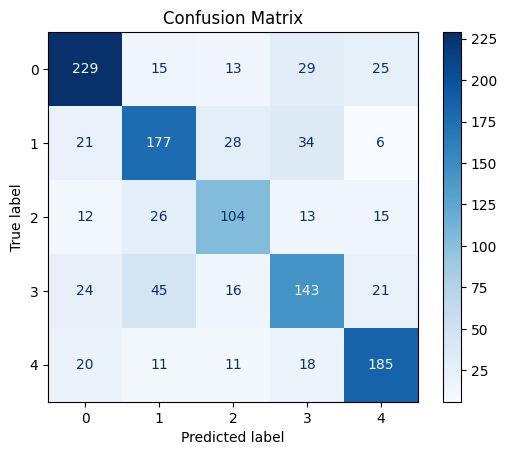

Accuracy: 67.5262
Report :
               precision    recall  f1-score   support

           0       0.75      0.74      0.74       311
           1       0.65      0.67      0.66       266
           2       0.60      0.61      0.61       170
           3       0.60      0.57      0.59       249
           4       0.73      0.76      0.74       245

    accuracy                           0.68      1241
   macro avg       0.67      0.67      0.67      1241
weighted avg       0.67      0.68      0.67      1241



In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for v, t, y in test_loader:
        v, t = v.to(device), t.to(device)
        outputs = model(v, t)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(all_labels, all_preds)
print(f"Accuracy: {accuracy:.4f}")
print("Report :\n", report)